# Vectorized MLP From Scratch
Pure NumPy implementation with manual backpropagation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

In [2]:
def one_hot(y,c): return np.eye(c)[y]
def relu(x): return np.maximum(0,x)
def relu_derivative(x): return (x>0).astype(float)
def softmax(x):
    x=x-np.max(x,axis=1,keepdims=True)
    e=np.exp(x); return e/np.sum(e,axis=1,keepdims=True)
def cross_entropy(y,p):
    p=np.clip(p,1e-12,1-1e-12)
    return -np.mean(np.sum(y*np.log(p),axis=1))
def accuracy(y,p):
    return np.mean(np.argmax(y,1)==np.argmax(p,1))


In [3]:
class MLP:
    def __init__(self,layers):
        self.layers=layers
        self.L=len(layers)-1
        self.W=[]; self.b=[]
        for i in range(self.L):
            self.W.append(np.random.randn(layers[i],layers[i+1])*np.sqrt(2/layers[i]))
            self.b.append(np.zeros((1,layers[i+1])))
    def forward(self,X):
        self.A=[X]; self.Z=[]
        A=X
        for i in range(self.L-1):
            Z=A@self.W[i]+self.b[i]
            A=relu(Z)
            self.Z.append(Z); self.A.append(A)
        Z=A@self.W[-1]+self.b[-1]
        self.Z.append(Z)
        out=softmax(Z)
        self.A.append(out)
        return out
    def backward(self,X,Y):
        m=X.shape[0]
        self.dW=[None]*self.L; self.db=[None]*self.L
        dZ=self.A[-1]-Y
        self.dW[-1]=self.A[-2].T@dZ/m
        self.db[-1]=np.sum(dZ,0,keepdims=True)/m
        dA=dZ@self.W[-1].T
        for i in range(self.L-2,-1,-1):
            dZ=dA*relu_derivative(self.Z[i])
            self.dW[i]=self.A[i].T@dZ/m
            self.db[i]=np.sum(dZ,0,keepdims=True)/m
            if i>0:
                dA=dZ@self.W[i].T
    def update(self,lr):
        for i in range(self.L):
            self.W[i]-=lr*self.dW[i]
            self.b[i]-=lr*self.db[i]
    def train(self,X,Y,epochs=500,lr=0.01):
        hist=[]
        for e in range(epochs):
            p=self.forward(X)
            loss=cross_entropy(Y,p)
            acc=accuracy(Y,p)
            self.backward(X,Y)
            self.update(lr)
            hist.append(loss)
            if e%50==0:
                print(f'Epoch {e} Loss={loss:.4f} Acc={acc:.4f}')
        return hist
    def predict(self,X):
        return np.argmax(self.forward(X),1)


In [4]:
samples=900
X=np.random.randn(samples,2)
y=np.zeros(samples,dtype=int)
y[(X[:,0]>0)&(X[:,1]>0)]=0
y[(X[:,0]<=0)&(X[:,1]>0)]=1
y[(X[:,0]<=0)&(X[:,1]<=0)]=2
y[(X[:,0]>0)&(X[:,1]<=0)]=3
Y=one_hot(y,4)
print(X.shape,Y.shape)

(900, 2) (900, 4)


In [5]:
model=MLP([2,64,32,16,4])

In [6]:
history=model.train(X,Y,epochs=500,lr=0.01)

Epoch 0 Loss=1.3308 Acc=0.2611
Epoch 50 Loss=0.6816 Acc=0.9233
Epoch 100 Loss=0.4179 Acc=0.9744
Epoch 150 Loss=0.2960 Acc=0.9833
Epoch 200 Loss=0.2317 Acc=0.9856
Epoch 250 Loss=0.1917 Acc=0.9878
Epoch 300 Loss=0.1648 Acc=0.9878
Epoch 350 Loss=0.1467 Acc=0.9878
Epoch 400 Loss=0.1332 Acc=0.9878
Epoch 450 Loss=0.1226 Acc=0.9878


In [7]:
pred=model.forward(X)
print("Accuracy:",accuracy(Y,pred))

Accuracy: 0.9888888888888889


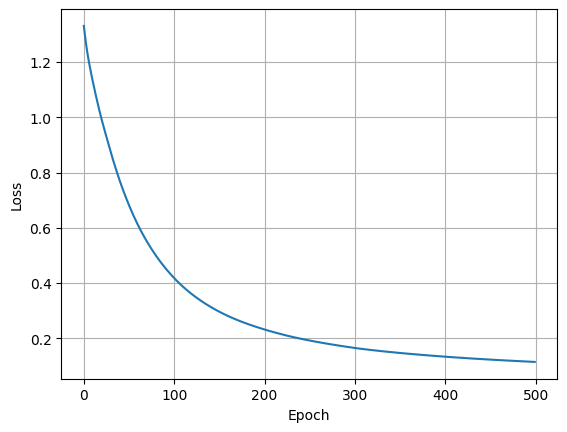

In [8]:
plt.plot(history)
plt.xlabel("Epoch");plt.ylabel("Loss");plt.grid();plt.show()

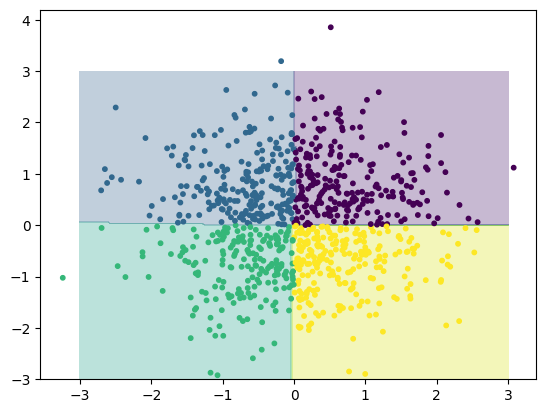

In [9]:
xx,yy=np.meshgrid(np.linspace(-3,3,200),np.linspace(-3,3,200))
grid=np.c_[xx.ravel(),yy.ravel()]
Z=model.predict(grid).reshape(xx.shape)
plt.contourf(xx,yy,Z,alpha=0.3)
plt.scatter(X[:,0],X[:,1],c=y,s=10)
plt.show()